In [26]:
import pandas as pd
df = pd.read_csv("C:\\Users\\chandini ch\\Downloads\\student_knn_regression.csv")
df.head(3)
print(df)
df.shape

    Study_Hours  Attendance  Assignments  Marks
0             1          60            1     35
1             2          62            1     38
2             3          65            2     42
3             4          68            2     47
4             5          70            3     52
5             6          72            3     58
6             7          75            4     63
7             8          78            4     68
8             9          80            5     72
9            10          82            5     76
10           11          84            6     80
11           12          86            6     84
12           13          88            7     87
13           14          90            7     90
14           15          92            8     93
15           16          94            8     95
16           17          95            9     97
17           18          96            9     98
18           19          97           10     99
19           20          98           10

(20, 4)

In [4]:
X = df[["Study_Hours","Attendance","Assignments"]]
y = df["Marks"]

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2,random_state=30)


In [9]:
#scaling the values
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)





In [86]:
from sklearn.neighbors import KNeighborsRegressor
knr = KNeighborsRegressor(n_neighbors=2)
knr.fit(X_train_scaled,y_train)
knr_predict = knr.predict(X_test_scaled)

3.875


<function matplotlib.pyplot.show(close=None, block=None)>

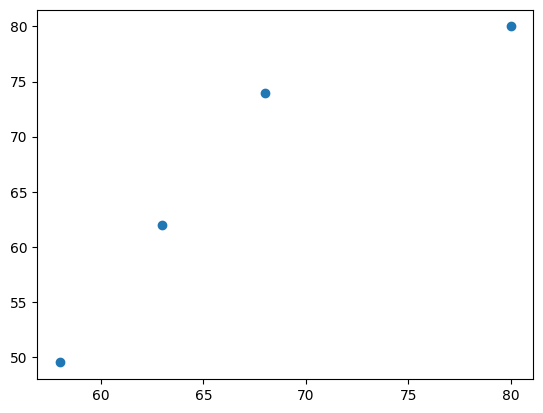

In [87]:
from sklearn.metrics import mean_absolute_error
from matplotlib import pyplot as plt
mab_error = mean_absolute_error(y_test,knr_predict)
print(mab_error)
plt.scatter(y_test,knr_predict)
plt.show

In [88]:
predict_df = pd.DataFrame({"Study_Hours":[30],"Attendance":[73],"Assignments":[6]})
predict_scaled_data = ss.transform(predict_df)
final_predicition = knr.predict(predict_scaled_data)
print(final_predicition)

[99.]


In [90]:
from math import sqrt
from sklearn.metrics import root_mean_squared_error
rmse = []
for k in range(12):
    k = k+1
    knr = KNeighborsRegressor(n_neighbors=k)
    knr.fit(X_train,y_train)
    knr_predict = knr.predict(X_test_scaled)
    error = sqrt(root_mean_squared_error(y_test,knr_predict))
    rmse.append(error)
    print("k value is:",k,"rmse is:",error)

k value is: 1 rmse is: 5.767829084697252
k value is: 2 rmse is: 5.640556403393735
k value is: 3 rmse is: 5.481573437194532
k value is: 4 rmse is: 5.288547299769001
k value is: 5 rmse is: 5.077174760036768
k value is: 6 rmse is: 4.606276808890575
k value is: 7 rmse is: 4.189419643212158
k value is: 8 rmse is: 3.7555985610733917
k value is: 9 rmse is: 3.3839798170380035
k value is: 10 rmse is: 3.0902015350640695
k value is: 11 rmse is: 2.9063454714827546
k value is: 12 rmse is: 2.8588532192885565


d:\anaconda\envs\hand\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
d:\anaconda\envs\hand\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
d:\anaconda\envs\hand\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
d:\anaconda\envs\hand\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
d:\anaconda\envs\hand\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
d:\anaconda\envs\hand\Lib

In [ ]:
knr_predict = knr.predict(X_test_scaled)
sub = pd.DataFrame({'predictions':knr_predict})
sub.to_csv("prediction_file",index = False)

In [80]:
Y_test_df = pd.DataFrame(y_test)
print(Y_test_df)

    Marks
7      68
10     80
5      58
6      63


In [81]:
sub1 = pd.DataFrame()
sub1["Study_Hours"] = X_test["Study_Hours"]
sub1["Attendance"] = X_test["Attendance"]
sub1["Assignments"] = X_test["Assignments"]
sub1["Actual_marks"] = Y_test_df["Marks"]
sub1["predicted_marks"] = knr_predict
sub1.to_csv("prediction_file_with_columns2",index = False)


In [66]:
import os
print(os.getcwd())

d:\Data Science\Regression


In [69]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': knr_predict
})

comparison.to_csv('comparison.csv', index=False)

In [77]:
print(y_test)

7     68
10    80
5     58
6     63
Name: Marks, dtype: int64


In [85]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor  
params = {'n_neighbors':[2,3,4,5,6,7,8,9,10,11,12,13,14,15]}

knn = KNeighborsRegressor()

model = GridSearchCV(knn, params, cv=3)
model.fit(X_train,y_train)
model.best_params_

d:\anaconda\envs\hand\Lib\site-packages\sklearn\model_selection\_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "d:\anaconda\envs\hand\Lib\site-packages\sklearn\model_selection\_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\anaconda\envs\hand\Lib\site-packages\sklearn\metrics\_scorer.py", line 485, in __call__
    return estimator.score(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\anaconda\envs\hand\Lib\site-packages\sklearn\base.py", line 653, in score
    y_pred = self.predict(X)
             ^^^^^^^^^^^^^^^
  File "d:\anaconda\envs\hand\Lib\site-packages\sklearn\neighbors\_regression.py", line 248, in predict
    neigh_ind = self.kneighbors(X, return_distance=False)
                ^^^^^^^^^^^^^^^^^^^

{'n_neighbors': 2}